In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("Visadataset.csv")

In [4]:
df.shape

(25480, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [6]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [7]:
df.sample(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
947,EZYV948,North America,Master's,Y,N,1337,2002,Midwest,105152.5700,Year,N,Certified
999,EZYV1000,Europe,Doctorate,N,Y,115,1965,South,48947.8500,Year,Y,Certified
17785,EZYV17786,Asia,Master's,N,N,741,1998,South,25621.9800,Year,Y,Certified
19231,EZYV19232,Asia,Master's,N,N,2894,1999,Midwest,135177.3600,Year,Y,Certified
15579,EZYV15580,Asia,Bachelor's,N,N,20971,2000,South,892.6323,Hour,Y,Denied


In [8]:
df['continent'].value_counts(normalize=True)

,proportion
continent,
Asia,0.661735
Europe,0.146468
North America,0.129199
South America,0.033438
Africa,0.021625
Oceania,0.007535


In [9]:
numeric_features=[feature for feature in df.columns if df[feature].dtype !='O']

In [10]:
categorical_features=[feature for feature in df.columns if df[feature].dtype =='O']

In [20]:
categorical_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [22]:
df['has_job_experience']

,has_job_experience
0,N
1,Y
2,N
3,N
4,Y
...,...
25475,Y
25476,Y
25477,Y
25478,Y


<Axes: xlabel='region_of_employment', ylabel='count'>

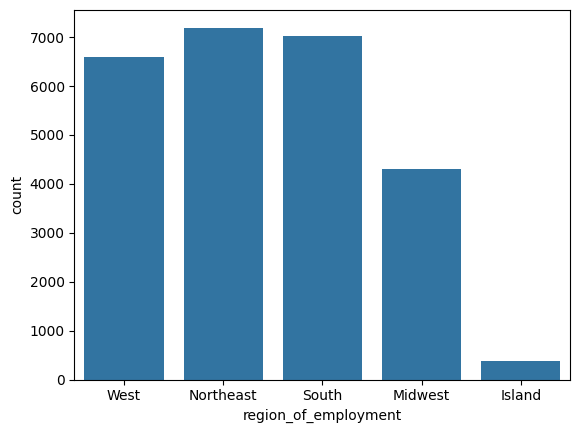

In [14]:
sns.countplot(x=df['region_of_employment'])

continent
education_of_employee
has_job_experience
requires_job_training
region_of_employment
unit_of_wage
full_time_position
case_status


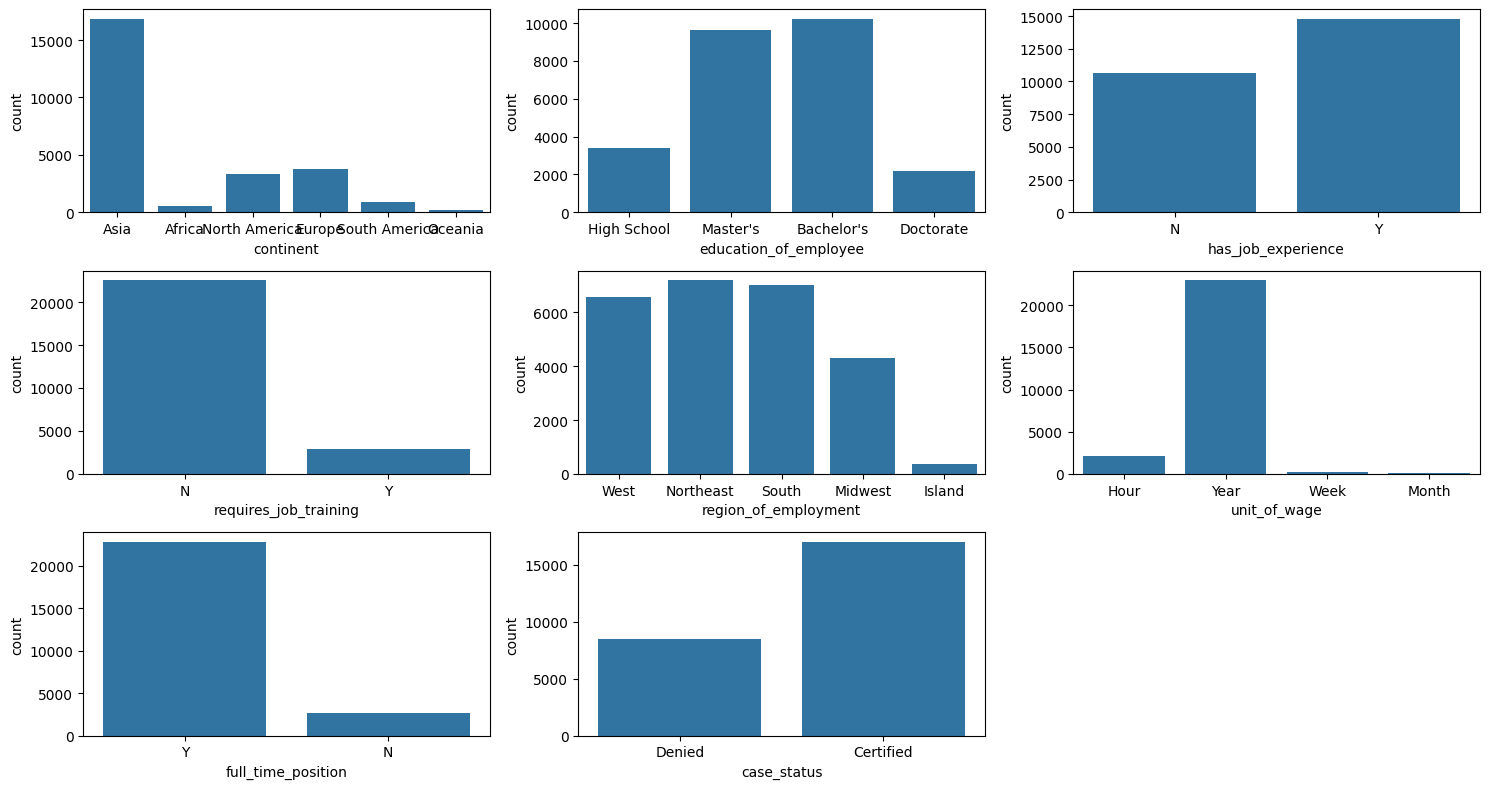

In [39]:
plt.figure(figsize=(15, 8))
for idx,i in enumerate(categorical_features,1):
  print(i)

  plt.subplot(3,3,idx)
  sns.countplot(x=df[i])
  plt.tight_layout()



/tmp/ipykernel_531/3600110801.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])
/tmp/ipykernel_531/3600110801.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])
/tmp/ipykernel_531/3600110801.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn 

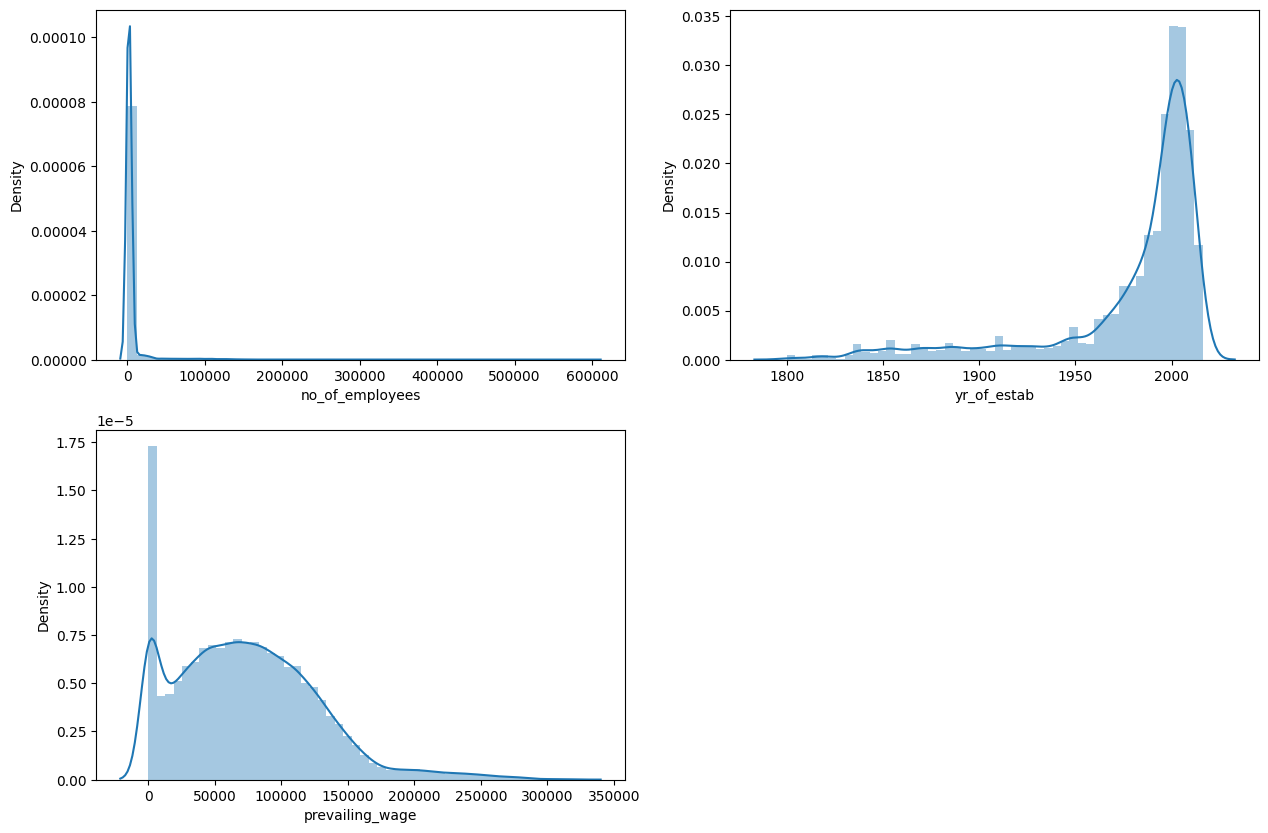

In [44]:
plt.figure(figsize=(15,10))
for i in numeric_features:
  plt.subplot(2,2,numeric_features.index(i)+1)
  sns.distplot(df[i])



In [42]:
numeric_features.index

<function list.index(value, start=0, stop=9223372036854775807, /)>

<Axes: xlabel='continent', ylabel='count'>

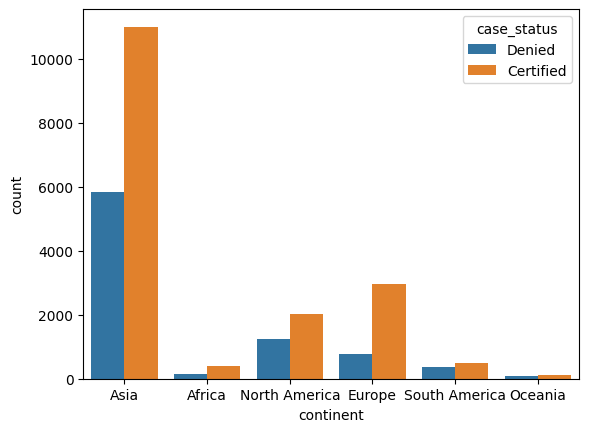

In [50]:
sns.countplot(x="continent",hue="case_status",data=df)

<Axes: xlabel='case_status', ylabel='yr_of_estab'>

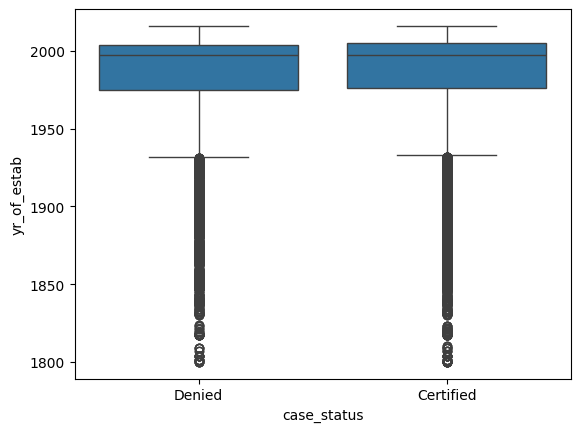

In [54]:
sns.boxplot(x="case_status",y="yr_of_estab",data=df)

/tmp/ipykernel_531/4062120739.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = order1[n]


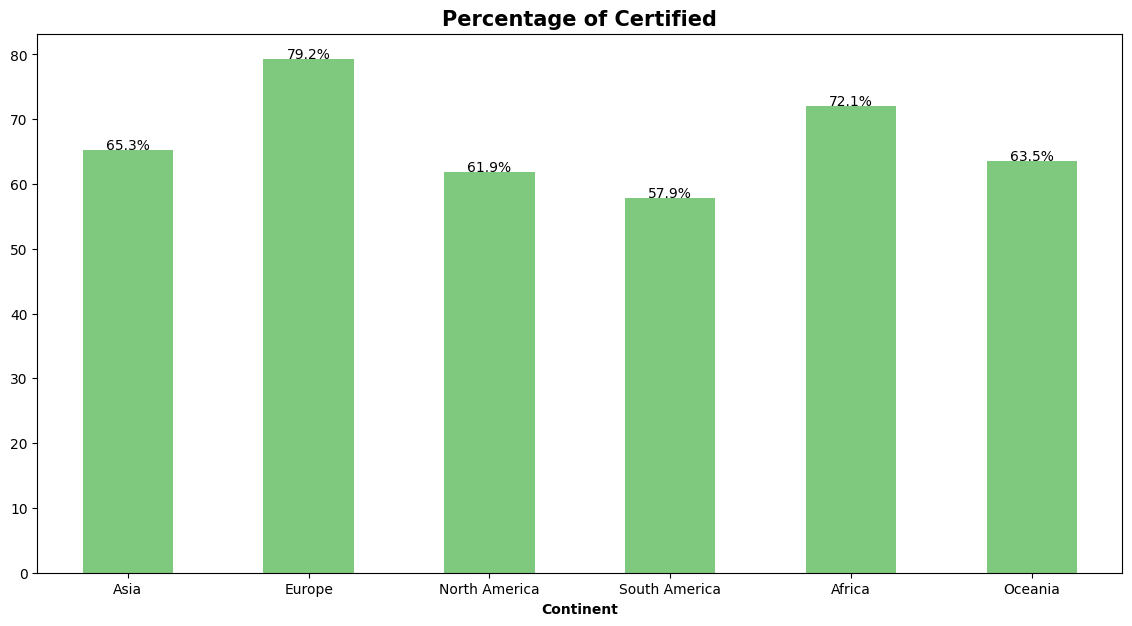

In [61]:
plt.figure(figsize=[14,7])

(100*df2[df2["case_status"].isin(['Certified'])]['continent'].value_counts()/df2['continent'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["case_status"].isin(['Certified'])]['continent'].value_counts()/df2['continent'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('Continent' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

In [60]:
df2=df.copy()

In [62]:
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [63]:
#education impact on visa


In [65]:
df.groupby('education_of_employee')['case_status'].value_counts(normalize=True)

education_of_employee  case_status
Bachelor's             Certified      0.622142
                       Denied         0.377858
Doctorate              Certified      0.872263
                       Denied         0.127737
High School            Denied         0.659649
                       Certified      0.340351
Master's               Certified      0.786278
                       Denied         0.213722
Name: proportion, dtype: float64

<Axes: xlabel='education_of_employee', ylabel='count'>

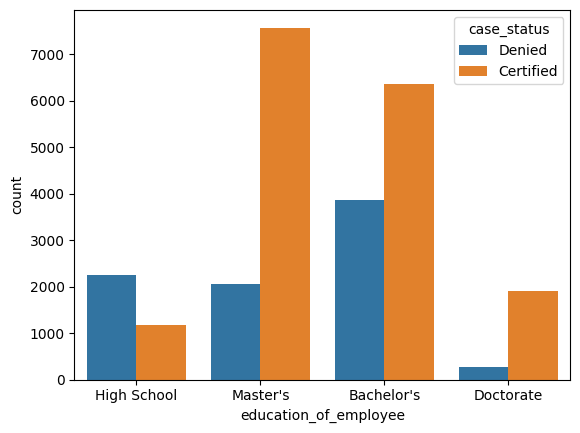

In [67]:
sns.countplot(x='education_of_employee',hue="case_status",data=df)

<Axes: xlabel='has_job_experience', ylabel='count'>

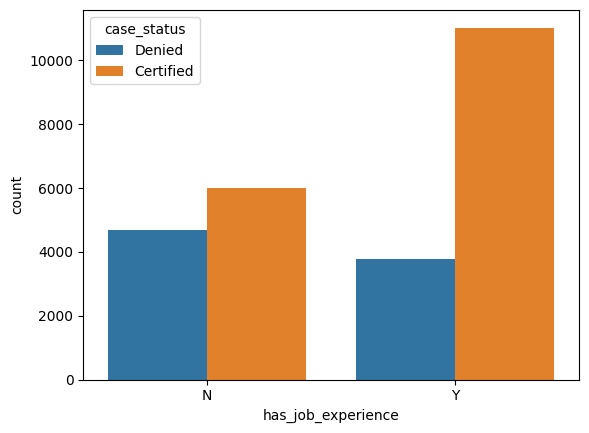

In [68]:
sns.countplot(x='has_job_experience',hue='case_status',data=df)